# 01 - Data Exploration

In this notebook, we check the credit default dataset before modeling. We look at the target balance, category codes, repayment behavior, credit utilization, payment amounts, accounting edge cases, and correlations.

## 1. Setup

We import the project modules from `src/credit_default` so the notebook uses the same definitions as the rest of the project.

In [1]:
%matplotlib inline

In [2]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from credit_default.data import (  # noqa: E402
    BILL_AMOUNT_COLUMNS,
    EDUCATION_DOCUMENTED_DOMAIN,
    LIMIT_COLUMN,
    MARRIAGE_DOCUMENTED_DOMAIN,
    PAY_AMOUNT_COLUMNS,
    PAY_STATUS_COLUMNS,
    TARGET_COLUMN,
    add_domain_features,
    load_credit_data,
)
from credit_default.eda import (  # noqa: E402
    build_categorical_distribution,
    build_data_quality_summary,
    build_high_correlation_pairs,
    build_domain_feature_summary,
    build_pay_status_distribution,
)

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"
TABLES_DIR = REPORTS_DIR / "tables"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

PROJECT_ROOT

WindowsPath('C:/Users/chris/OneDrive/Dokumente/projet/credit client')

## 2. Load Data

The raw Excel file has one metadata row before the business column names. The loader reads the useful header and standardizes the target column.

In [3]:
df = load_credit_data()

print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
display(df.head())

Shape: 30,000 rows x 25 columns


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default_payment_next_month
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [4]:
# Compact view of data types and completeness.
schema = (
    pd.DataFrame({
        "feature": df.columns,
        "dtype": df.dtypes.astype(str).values,
        "missing": df.isna().sum().values,
        "unique_values": df.nunique().values,
    })
)
display(schema)

,feature,dtype,missing,unique_values
0,ID,int64,0,30000
1,LIMIT_BAL,int64,0,81
2,SEX,int64,0,2
3,EDUCATION,int64,0,7
4,MARRIAGE,int64,0,4
5,AGE,int64,0,56
6,PAY_0,int64,0,11
7,PAY_2,int64,0,11
8,PAY_3,int64,0,11
9,PAY_4,int64,0,11


### Variable Groups

The dataset contains a credit limit, demographic fields, six repayment-status variables, six bill amounts, six payment amounts, and a binary next-month default target.

`PAY_*` values need careful handling because inactive accounts, timely payment, revolving credit, and positive delays are different behavioral states.

## 3. Data Quality Checks

Before modeling, we check missing values, duplicate IDs, category codes, and accounting edge cases. This helps decide what should be cleaned and what should be kept as signal.

In [5]:
quality = build_data_quality_summary(df)
display(quality)

,check,value,comment
0,row_count,30000,Expected 30000 for the canonical dataset.
1,column_count,25,Expected 25 including ID and target.
2,missing_cells,0,Missing values should be audited.
3,duplicate_id_count,0,ID should be unique.
4,target_default_rate,0.2212,Class imbalance checkpoint.
5,unexpected_education_codes,"0,5,6",Undocumented codes should be grouped with 'oth...
6,unexpected_education_rows,345,Rows outside documented EDUCATION codes 1-4.
7,unexpected_marriage_codes,0,Code 0 is not part of the documented MARRIAGE ...
8,unexpected_marriage_rows,54,Rows outside documented MARRIAGE codes 1-3.
9,unexpected_pay_status_rows,0,Rows outside PAY_* documented domain -2 to 9.


In [6]:
# Detail undocumented codes in categorical variables.
for column, documented_domain in {
    "EDUCATION": EDUCATION_DOCUMENTED_DOMAIN,
    "MARRIAGE": MARRIAGE_DOCUMENTED_DOMAIN,
}.items():
    values = df[column].value_counts().sort_index().rename_axis(column).reset_index(name="n")
    values["documented"] = values[column].isin(documented_domain)
    values["share"] = values["n"] / len(df)
    print(f"\n{column}")
    display(values)


EDUCATION


,EDUCATION,n,documented,share
0,0,14,False,0.0005
1,1,10585,True,0.3528
2,2,14030,True,0.4677
3,3,4917,True,0.1639
4,4,123,True,0.0041
5,5,280,False,0.0093
6,6,51,False,0.0017



MARRIAGE


,MARRIAGE,n,documented,share
0,0,54,False,0.0018
1,1,13659,True,0.4553
2,2,15964,True,0.5321
3,3,323,True,0.0108


**Findings.** The dataset is complete and IDs are unique. `EDUCATION=0/5/6` and `MARRIAGE=0` are undocumented codes, so they should be grouped into explicit `other_unknown` categories rather than dropped.

## 4. Target Distribution

Default is the minority class, so accuracy alone is not a reliable model metric. Ranking and classification metrics should be evaluated together.

,default_next_month,n,share
0,0,23364,0.7788
1,1,6636,0.2212


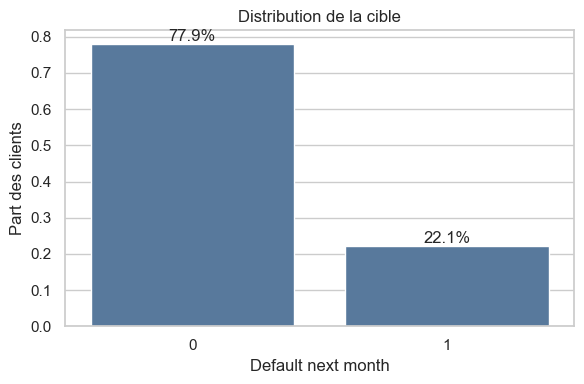

In [7]:
target_counts = (
    df[TARGET_COLUMN]
    .value_counts()
    .sort_index()
    .rename_axis("default_next_month")
    .reset_index(name="n")
)
target_counts["share"] = target_counts["n"] / len(df)
display(target_counts)

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=target_counts, x="default_next_month", y="share", color="#4C78A8", ax=ax)
ax.set_title("Distribution de la cible")
ax.set_xlabel("Default next month")
ax.set_ylabel("Part des clients")
ax.bar_label(ax.containers[0], fmt="%.1f%%", labels=[f"{100*x:.1f}%" for x in target_counts["share"]])
plt.tight_layout()
plt.show()

**Findings.** The default rate is around 22%. The target is imbalanced, so we should not rely only on accuracy. PR-AUC, recall, F1, and calibration are more useful here.

## 5. Demographic Variables

Demographic variables are useful for profiling and segmentation. They should be handled carefully and kept interpretable.

In [8]:
categorical_distribution = build_categorical_distribution(df)
display(categorical_distribution)

,feature,value,n,defaults,default_rate,share
0,SEX,1,11888,2873,0.2417,0.3963
1,SEX,2,18112,3763,0.2078,0.6037
2,EDUCATION,0,14,0,0.0000,0.0005
3,EDUCATION,1,10585,2036,0.1923,0.3528
4,EDUCATION,2,14030,3330,0.2373,0.4677
5,EDUCATION,3,4917,1237,0.2516,0.1639
6,EDUCATION,4,123,7,0.0569,0.0041
7,EDUCATION,5,280,18,0.0643,0.0093
8,EDUCATION,6,51,8,0.1569,0.0017
9,MARRIAGE,0,54,5,0.0926,0.0018


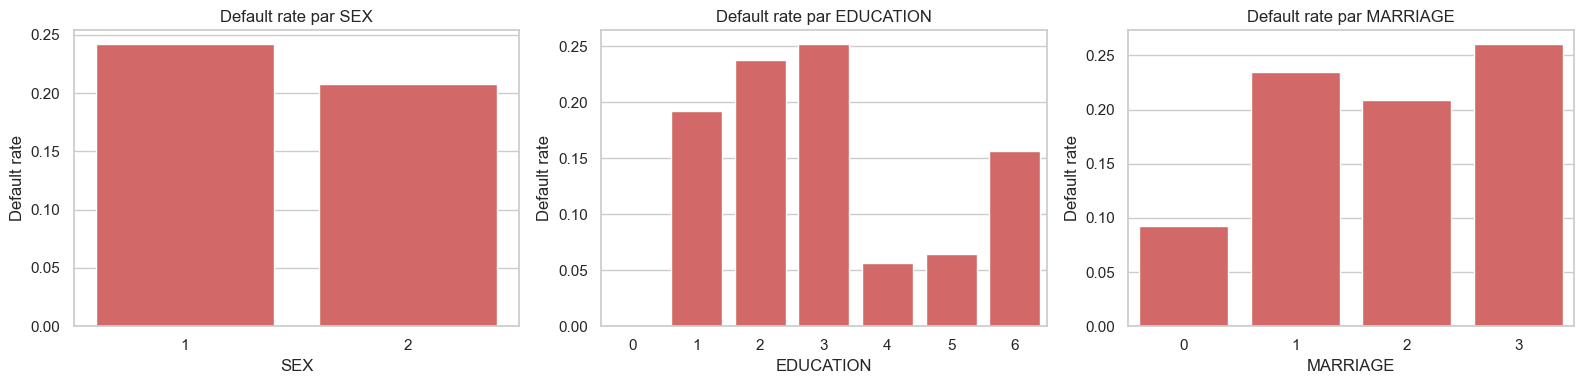

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, column in zip(axes, ["SEX", "EDUCATION", "MARRIAGE"]):
    table = categorical_distribution.query("feature == @column").copy()
    sns.barplot(data=table, x="value", y="default_rate", color="#E45756", ax=ax)
    ax.set_title(f"Default rate par {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("Default rate")
plt.tight_layout()
plt.show()

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
LIMIT_BAL,"30,000.0000","167,484.3227","129,747.6616","10,000.0000","10,000.0000","20,000.0000","50,000.0000","140,000.0000","240,000.0000","430,000.0000","500,000.0000","1,000,000.0000"
AGE,"30,000.0000",35.4855,9.2179,21.0000,22.0000,23.0000,28.0000,34.0000,41.0000,53.0000,60.0000,79.0000


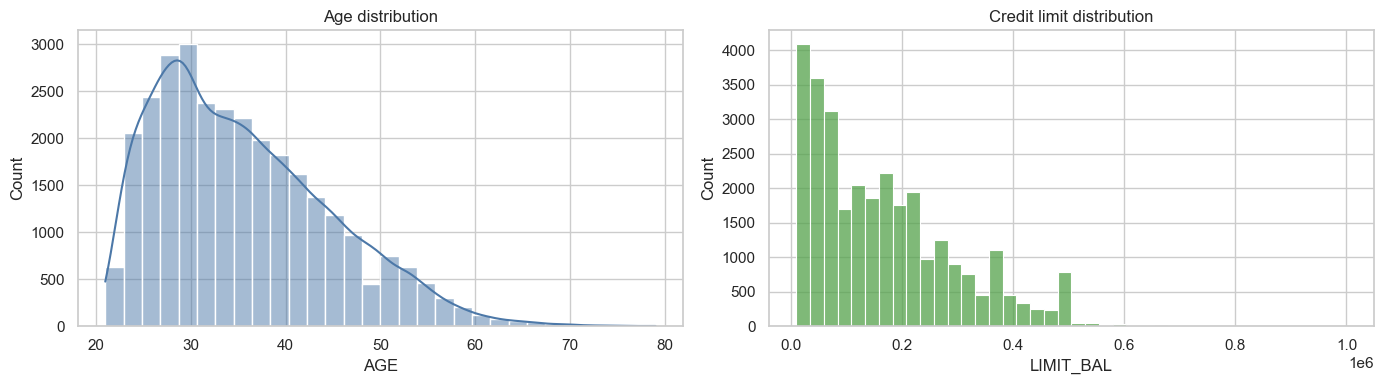

In [10]:
# AGE and LIMIT_BAL are reviewed as distributions and binned risk profiles.
numeric_profile = df[[LIMIT_COLUMN, "AGE"]].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T
display(numeric_profile)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df["AGE"], bins=30, kde=True, ax=axes[0], color="#4C78A8")
axes[0].set_title("Age distribution")
axes[0].set_xlabel("AGE")

sns.histplot(df[LIMIT_COLUMN], bins=40, kde=False, ax=axes[1], color="#54A24B")
axes[1].set_title("Credit limit distribution")
axes[1].set_xlabel("LIMIT_BAL")
plt.tight_layout()
plt.show()

,limit_decile,n,defaults,default_rate
0,"(9999.999, 30000.0]",4081,1463,0.3585
1,"(30000.0, 50000.0]",3595,977,0.2718
2,"(50000.0, 70000.0]",1556,443,0.2847
3,"(70000.0, 100000.0]",3266,801,0.2453
4,"(100000.0, 140000.0]",2792,638,0.2285
5,"(140000.0, 180000.0]",3331,578,0.1735
6,"(180000.0, 210000.0]",2487,436,0.1753
7,"(210000.0, 270000.0]",2934,478,0.1629
8,"(270000.0, 360000.0]",3482,528,0.1516
9,"(360000.0, 1000000.0]",2476,294,0.1187


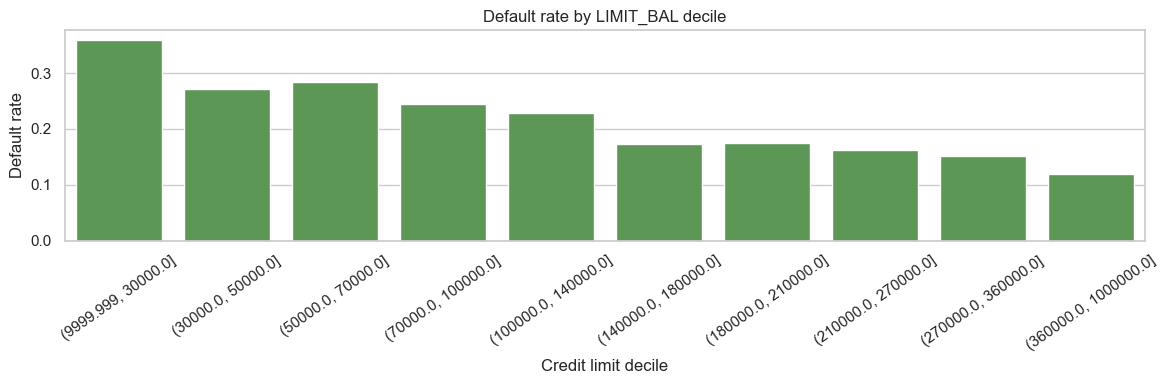

In [11]:
# Credit-limit deciles make the risk pattern easier to read than raw values.
limit_bins = df[[LIMIT_COLUMN, TARGET_COLUMN]].copy()
limit_bins["limit_decile"] = pd.qcut(limit_bins[LIMIT_COLUMN], q=10, duplicates="drop")
limit_default = (
    limit_bins.groupby("limit_decile", observed=False)[TARGET_COLUMN]
    .agg(n="size", defaults="sum", default_rate="mean")
    .reset_index()
)
limit_default["limit_decile"] = limit_default["limit_decile"].astype(str)
display(limit_default)

fig, ax = plt.subplots(figsize=(12, 4))
sns.barplot(data=limit_default, x="limit_decile", y="default_rate", color="#54A24B", ax=ax)
ax.set_title("Default rate by LIMIT_BAL decile")
ax.set_xlabel("Credit limit decile")
ax.set_ylabel("Default rate")
ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()

**Findings.** Lower credit-limit bands tend to show higher default rates, which is consistent with basic credit-risk segmentation.

## 6. Repayment Status

Repayment history is expected to carry strong signal. The analysis checks both month-level repayment states and aggregated delinquency counts.

In [12]:
pay_status_distribution = build_pay_status_distribution(df)
display(pay_status_distribution.head(20))

,feature,status,n,defaults,default_rate,share
0,PAY_0,-2,2759,365,0.1323,0.0920
1,PAY_0,-1,5686,954,0.1678,0.1895
2,PAY_0,0,14737,1888,0.1281,0.4912
3,PAY_0,1,3688,1252,0.3395,0.1229
4,PAY_0,2,2667,1844,0.6914,0.0889
5,PAY_0,3,322,244,0.7578,0.0107
6,PAY_0,4,76,52,0.6842,0.0025
7,PAY_0,5,26,13,0.5000,0.0009
8,PAY_0,6,11,6,0.5455,0.0004
9,PAY_0,7,9,7,0.7778,0.0003


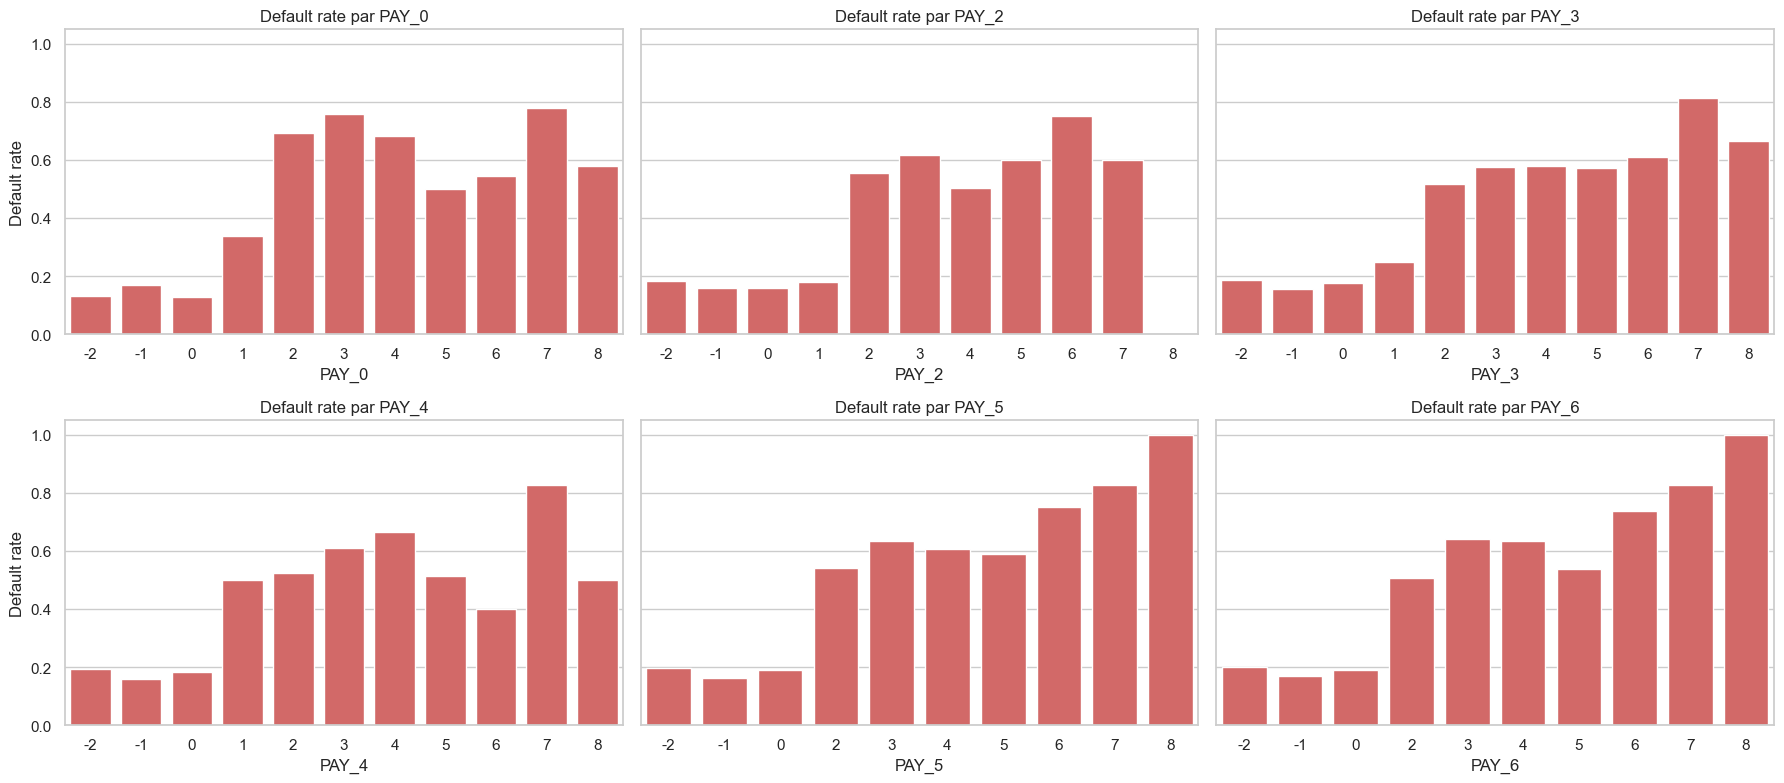

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharey=True)
for ax, column in zip(axes.ravel(), PAY_STATUS_COLUMNS):
    table = pay_status_distribution.query("feature == @column")
    sns.barplot(data=table, x="status", y="default_rate", color="#E45756", ax=ax)
    ax.set_title(f"Default rate par {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("Default rate")
plt.tight_layout()
plt.show()

,PAY_0,n,defaults,default_rate
0,-2,2759,365,0.1323
1,-1,5686,954,0.1678
2,0,14737,1888,0.1281
3,1,3688,1252,0.3395
4,2,2667,1844,0.6914
5,3,322,244,0.7578
6,4,76,52,0.6842
7,5,26,13,0.5000
8,6,11,6,0.5455
9,7,9,7,0.7778


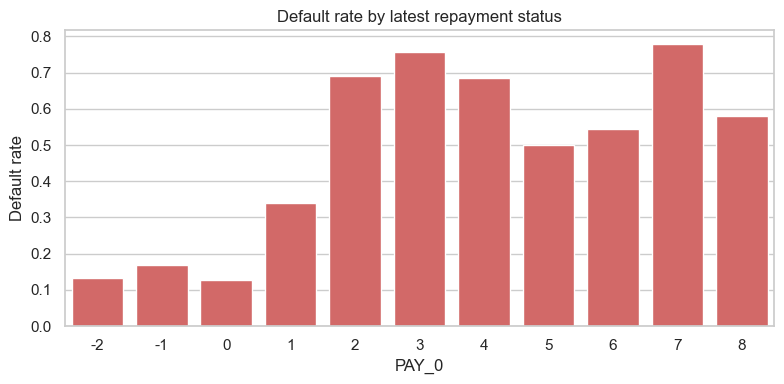

In [14]:
# PAY_0 is the most recent repayment status and is expected to be highly predictive.
pay0_table = (
    df.groupby("PAY_0", observed=False)[TARGET_COLUMN]
    .agg(n="size", defaults="sum", default_rate="mean")
    .reset_index()
)
display(pay0_table)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=pay0_table, x="PAY_0", y="default_rate", color="#E45756", ax=ax)
ax.set_title("Default rate by latest repayment status")
ax.set_xlabel("PAY_0")
ax.set_ylabel("Default rate")
plt.tight_layout()
plt.show()

,delinquency_months,n,defaults,default_rate
0,0,19931,2334,0.1171
1,1,4426,1320,0.2982
2,2,1899,736,0.3876
3,3,1154,587,0.5087
4,4,951,545,0.5731
5,5,298,171,0.5738
6,6,1341,943,0.7032


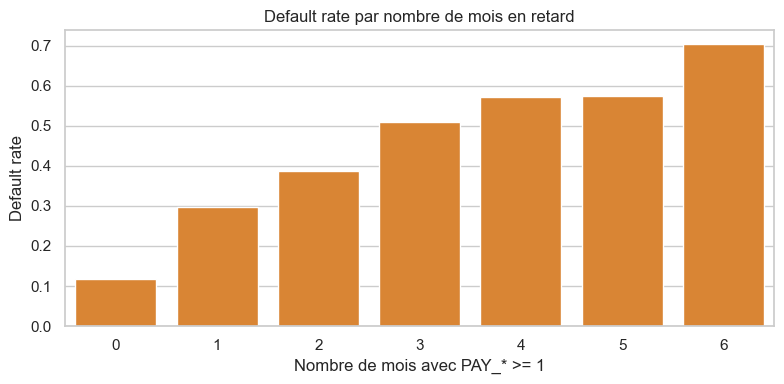

In [ ]:
# Temporal repayment aggregates capture delay frequency and severity.
df_features = add_domain_features(df)

delinquency_table = (
    df_features.groupby("delinquency_months", observed=False)[TARGET_COLUMN]
    .agg(n="size", defaults="sum", default_rate="mean")
    .reset_index()
)
display(delinquency_table)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=delinquency_table, x="delinquency_months", y="default_rate", color="#F58518", ax=ax)
ax.set_title("Default rate par nombre de mois en retard")
ax.set_xlabel("Nombre de mois avec PAY_* >= 1")
ax.set_ylabel("Default rate")
plt.tight_layout()
plt.show()

**Findings.** Default rates increase sharply with recent delay status and with the number of delinquent months. Aggregated delinquency features are stable, interpretable predictors.

## 7. Bill Amounts, Payments, and Accounting Edge Cases

Bill and payment amounts are skewed and repeated across adjacent months. Raw amounts are useful, but ratios are needed to compare clients with different credit limits.

In [16]:
amount_summary = df[BILL_AMOUNT_COLUMNS + PAY_AMOUNT_COLUMNS].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
).T
display(amount_summary)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
BILL_AMT1,"30,000.0000","51,223.3309","73,635.8606","-165,580.0000",-81.0000,0.0000,"3,558.7500","22,381.5000","67,091.0000","201,203.0500","350,110.6800","964,511.0000"
BILL_AMT2,"30,000.0000","49,179.0752","71,173.7688","-69,777.0000",-200.0000,0.0000,"2,984.7500","21,200.0000","64,006.2500","194,792.2000","337,495.2800","983,931.0000"
BILL_AMT3,"30,000.0000","47,013.1548","69,349.3874","-157,264.0000",-200.0000,0.0000,"2,666.2500","20,088.5000","60,164.7500","187,821.0500","325,030.3900","1,664,089.0000"
BILL_AMT4,"30,000.0000","43,262.9490","64,332.8561","-170,000.0000",-212.0200,0.0000,"2,326.7500","19,052.0000","54,506.0000","174,333.3500","304,997.2700","891,586.0000"
BILL_AMT5,"30,000.0000","40,311.4010","60,797.1558","-81,334.0000",-232.0100,0.0000,"1,763.0000","18,104.5000","50,190.5000","165,794.3000","285,868.3300","927,171.0000"
BILL_AMT6,"30,000.0000","38,871.7604","59,554.1075","-339,603.0000",-331.0300,0.0000,"1,256.0000","17,071.0000","49,198.2500","161,912.0000","279,505.0600","961,664.0000"
PAY_AMT1,"30,000.0000","5,663.5805","16,563.2804",0.0000,0.0000,0.0000,"1,000.0000","2,100.0000","5,006.0000","18,428.2000","66,522.1800","873,552.0000"
PAY_AMT2,"30,000.0000","5,921.1635","23,040.8704",0.0000,0.0000,0.0000,833.0000,"2,009.0000","5,000.0000","19,004.3500","76,651.0200","1,684,259.0000"
PAY_AMT3,"30,000.0000","5,225.6815","17,606.9615",0.0000,0.0000,0.0000,390.0000,"1,800.0000","4,505.0000","17,589.4000","70,000.0000","896,040.0000"
PAY_AMT4,"30,000.0000","4,826.0769","15,666.1597",0.0000,0.0000,0.0000,296.0000,"1,500.0000","4,013.2500","16,014.9500","67,054.4400","621,000.0000"


In [17]:
amount_flags = []
for column in BILL_AMOUNT_COLUMNS + PAY_AMOUNT_COLUMNS:
    amount_flags.append({
        "feature": column,
        "negative_rows": int((df[column] < 0).sum()),
        "zero_rows": int((df[column] == 0).sum()),
        "above_limit_rows": int((df[column] > df[LIMIT_COLUMN]).sum()) if column in BILL_AMOUNT_COLUMNS else np.nan,
        "p99": df[column].quantile(0.99),
        "max": df[column].max(),
    })
amount_flags = pd.DataFrame(amount_flags)
display(amount_flags)

,feature,negative_rows,zero_rows,above_limit_rows,p99,max
0,BILL_AMT1,590,2008,"2,115.0000","350,110.6800",964511
1,BILL_AMT2,669,2506,"1,940.0000","337,495.2800",983931
2,BILL_AMT3,655,2870,"1,583.0000","325,030.3900",1664089
3,BILL_AMT4,675,3195,"1,018.0000","304,997.2700",891586
4,BILL_AMT5,655,3506,820.0000,"285,868.3300",927171
5,BILL_AMT6,688,4020,798.0000,"279,505.0600",961664
6,PAY_AMT1,0,5249,NaN,"66,522.1800",873552
7,PAY_AMT2,0,5396,NaN,"76,651.0200",1684259
8,PAY_AMT3,0,5968,NaN,"70,000.0000",896040
9,PAY_AMT4,0,6408,NaN,"67,054.4400",621000


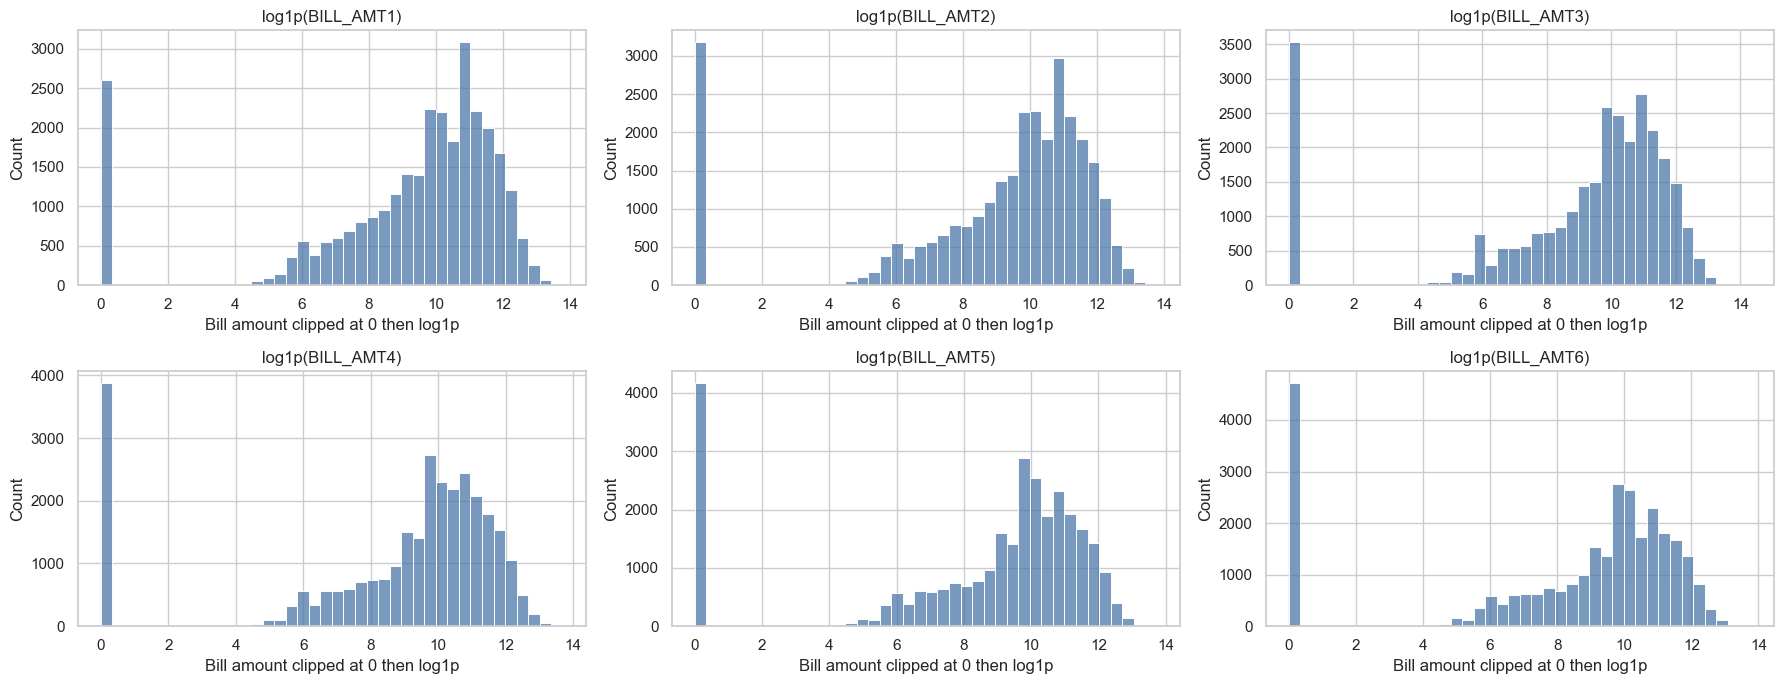

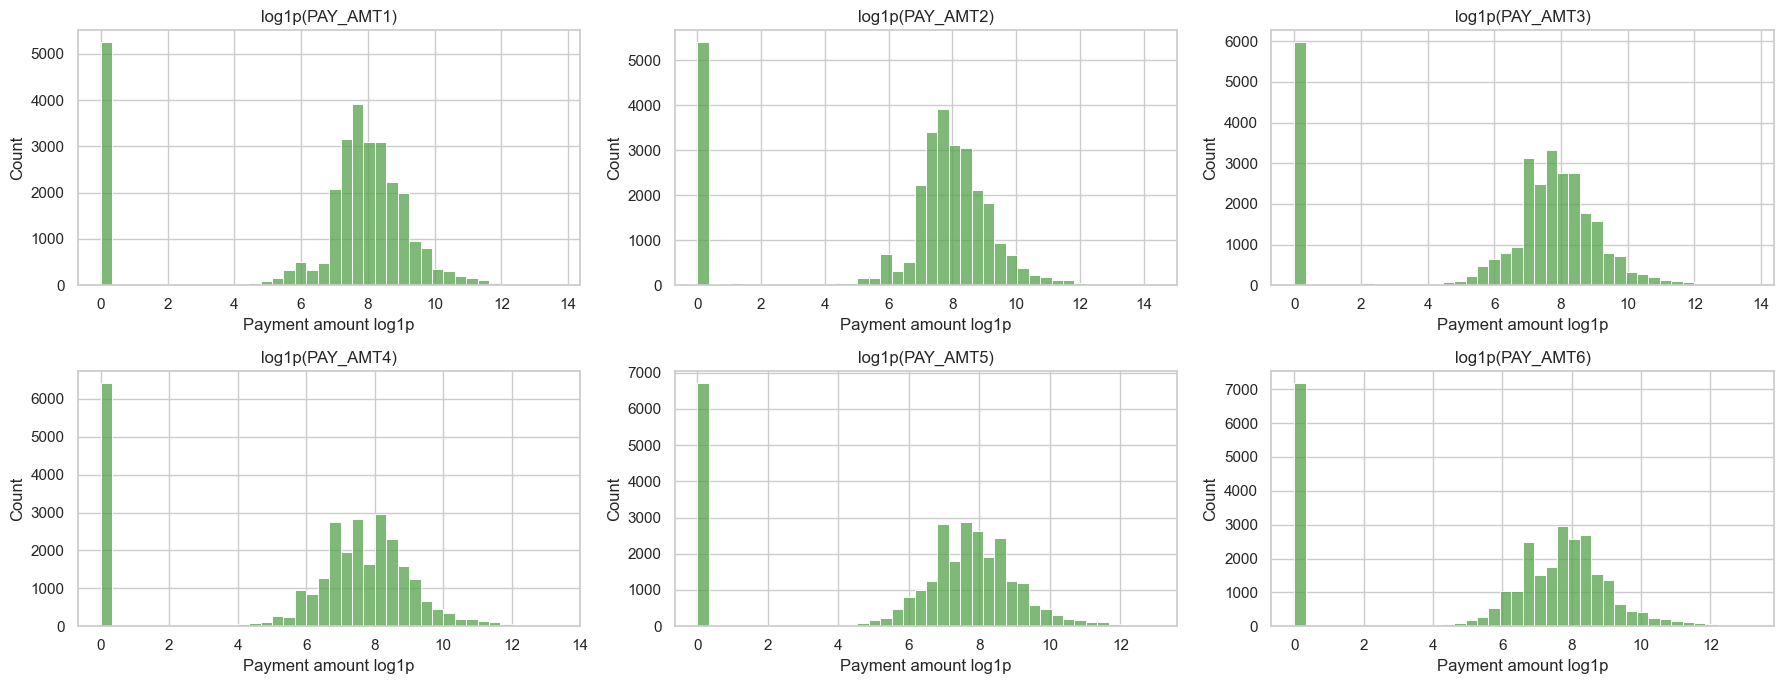

In [18]:
# Use log1p visualization to reduce the effect of very large amounts.
fig, axes = plt.subplots(2, 3, figsize=(18, 7), sharey=False)
for ax, column in zip(axes.ravel(), BILL_AMOUNT_COLUMNS):
    values = np.log1p(df[column].clip(lower=0))
    sns.histplot(values, bins=40, ax=ax, color="#4C78A8")
    ax.set_title(f"log1p({column})")
    ax.set_xlabel("Bill amount clipped at 0 then log1p")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(18, 7), sharey=False)
for ax, column in zip(axes.ravel(), PAY_AMOUNT_COLUMNS):
    values = np.log1p(df[column])
    sns.histplot(values, bins=40, ax=ax, color="#54A24B")
    ax.set_title(f"log1p({column})")
    ax.set_xlabel("Payment amount log1p")
plt.tight_layout()
plt.show()

**Findings.** Amount distributions are highly skewed. Negative bill amounts are better treated as accounting adjustments or credits than as missing values.

## 8. Domain Features

The next feature set should translate raw credit behavior into utilization, repayment capacity, and delinquency indicators.

In [19]:
domain_feature_summary = build_domain_feature_summary(df)
display(domain_feature_summary)

,feature,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
0,delinquency_months,"30,000.0000",0.8342,1.5543,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,5.0000,6.0000,6.0000
1,severe_delinquency_months,"30,000.0000",0.7101,1.4647,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,5.0000,6.0000,6.0000
2,max_delay_status,"30,000.0000",0.4387,1.3452,-2.0000,-2.0000,-2.0000,0.0000,0.0000,2.0000,2.0000,4.0000,8.0000
3,recent_delay_status,"30,000.0000",-0.0167,1.1238,-2.0000,-2.0000,-2.0000,-1.0000,0.0000,0.0000,2.0000,3.0000,8.0000
4,max_utilization,"30,000.0000",0.4950,0.4330,-0.1000,0.0000,0.0032,0.0706,0.4307,0.9232,1.0334,1.5775,10.6886
5,mean_utilization,"30,000.0000",0.3730,0.3519,-0.2326,0.0000,0.0010,0.0300,0.2848,0.6879,0.9598,1.0484,5.3643
6,total_bill_amount,"30,000.0000","269,861.6712","379,564.3312","-336,259.0000",0.0000,"1,167.8500","28,688.0000","126,311.0000","342,626.5000","1,046,422.0500","1,801,729.1600","5,263,883.0000"
7,total_payment_amount,"30,000.0000","31,651.3926","60,827.6779",0.0000,0.0000,220.4000,"6,679.7500","14,383.0000","33,503.5000","118,317.0500","270,603.9400","3,764,066.0000"
8,total_payment_to_bill,"28,929.0000",0.4865,5.6070,0.0000,0.0000,0.0296,0.0425,0.0945,0.6229,1.1868,2.8198,797.0000
9,mean_payment_to_bill,"29,034.0000",1.7466,32.5435,0.0000,0.0000,0.0152,0.0412,0.0847,0.8896,4.6370,17.8431,"4,444.1333"


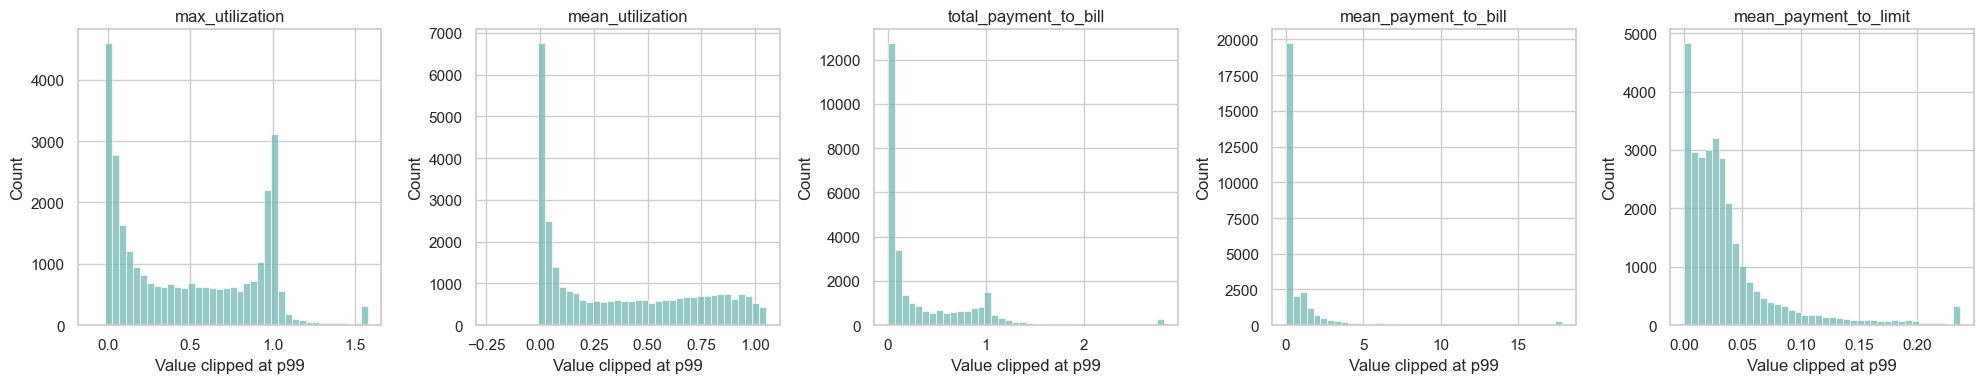

In [20]:
ratio_columns = [
    "max_utilization",
    "mean_utilization",
    "total_payment_to_bill",
    "mean_payment_to_bill",
    "mean_payment_to_limit",
]

fig, axes = plt.subplots(1, len(ratio_columns), figsize=(20, 4))
for ax, column in zip(axes, ratio_columns):
    # Visual clipping only; raw values are kept for calculations.
    upper = df_features[column].quantile(0.99)
    sns.histplot(df_features[column].clip(upper=upper), bins=40, ax=ax, color="#72B7B2")
    ax.set_title(column)
    ax.set_xlabel("Value clipped at p99")
plt.tight_layout()
plt.show()

,max_utilization_decile,n,defaults,default_rate
0,"(-0.101, 0.0114]",3000,818,0.2727
1,"(0.0114, 0.0429]",3000,547,0.1823
2,"(0.0429, 0.11]",3000,451,0.1503
3,"(0.11, 0.238]",3000,426,0.1420
4,"(0.238, 0.431]",3000,529,0.1763
5,"(0.431, 0.63]",3000,664,0.2213
6,"(0.63, 0.841]",3000,730,0.2433
7,"(0.841, 0.97]",3000,784,0.2613
8,"(0.97, 1.012]",3000,760,0.2533
9,"(1.012, 1.577]",3000,927,0.3090


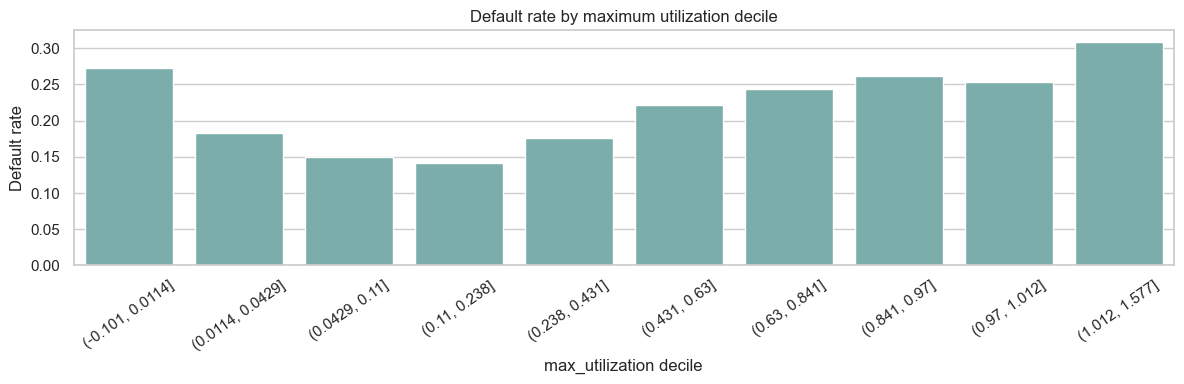

In [21]:
# Relationship between maximum utilization and default by decile.
utilization = df_features[["max_utilization", TARGET_COLUMN]].dropna().copy()
utilization["max_utilization_decile"] = pd.qcut(
    utilization["max_utilization"].clip(upper=utilization["max_utilization"].quantile(0.99)),
    q=10,
    duplicates="drop",
)
utilization_default = (
    utilization.groupby("max_utilization_decile", observed=False)[TARGET_COLUMN]
    .agg(n="size", defaults="sum", default_rate="mean")
    .reset_index()
)
utilization_default["max_utilization_decile"] = utilization_default["max_utilization_decile"].astype(str)
display(utilization_default)

fig, ax = plt.subplots(figsize=(12, 4))
sns.barplot(data=utilization_default, x="max_utilization_decile", y="default_rate", color="#72B7B2", ax=ax)
ax.set_title("Default rate by maximum utilization decile")
ax.set_xlabel("max_utilization decile")
ax.set_ylabel("Default rate")
ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()

**Findings.** Ratio features are closer to the business question than raw amounts alone. They compare exposure and repayment behavior relative to the credit line.

## 9. Correlation and Redundancy

Adjacent monthly bill amounts are mechanically correlated because balances roll over through time. This matters for linear models and feature interpretation.

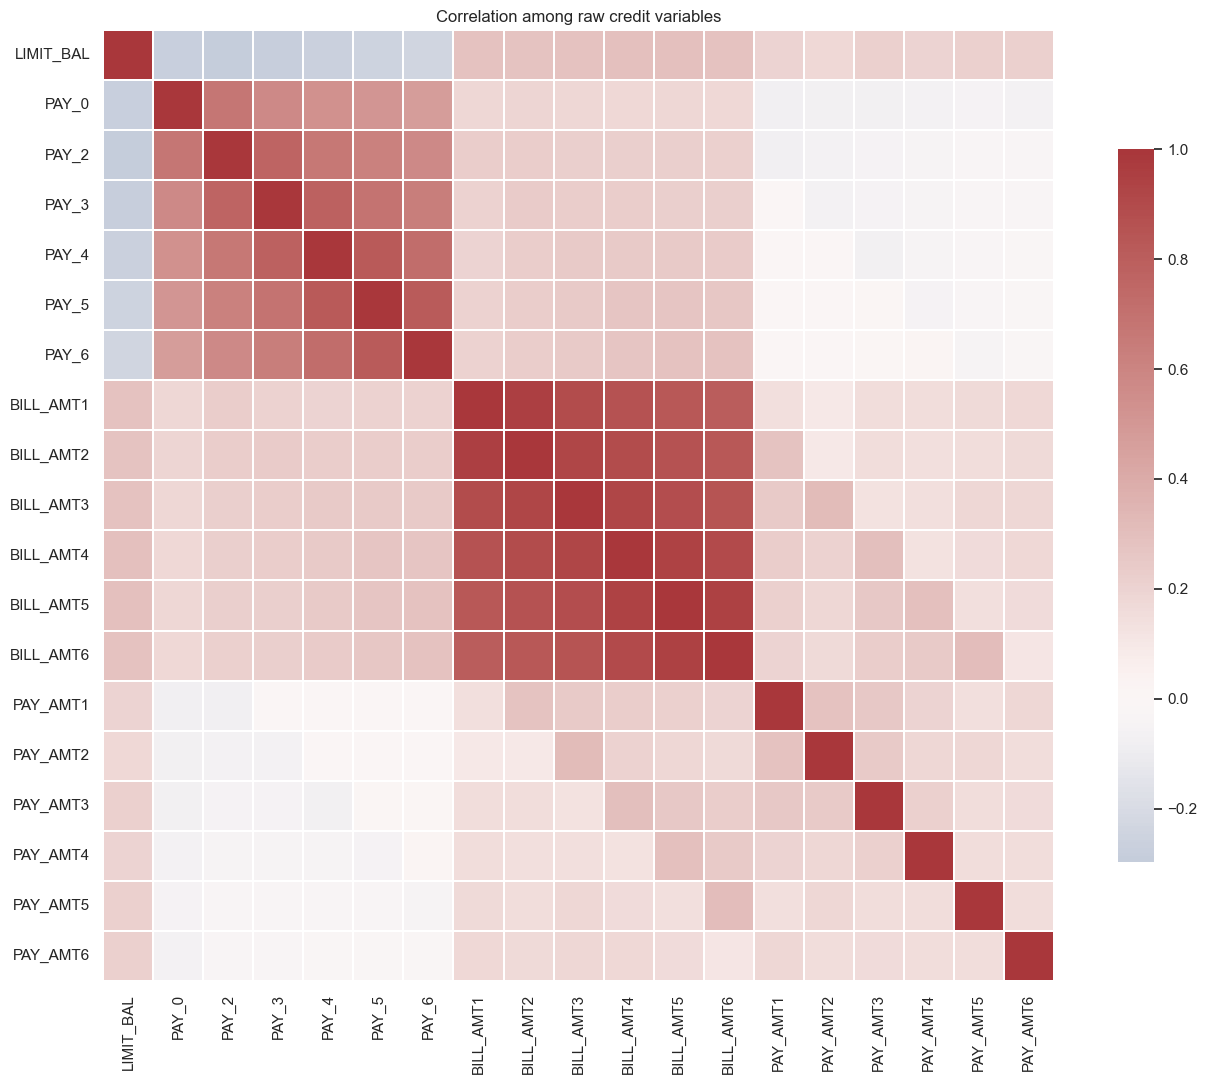

In [22]:
raw_credit_columns = [LIMIT_COLUMN] + PAY_STATUS_COLUMNS + BILL_AMOUNT_COLUMNS + PAY_AMOUNT_COLUMNS
corr = df[raw_credit_columns].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    corr,
    cmap="vlag",
    center=0,
    square=True,
    linewidths=0.2,
    cbar_kws={"shrink": 0.75},
    ax=ax,
)
ax.set_title("Correlation among raw credit variables")
plt.tight_layout()
plt.show()

In [23]:
high_corr = build_high_correlation_pairs(df)
display(high_corr.head(20))

,feature_1,feature_2,correlation,abs_correlation
0,BILL_AMT1,BILL_AMT2,0.9515,0.9515
1,BILL_AMT5,BILL_AMT6,0.9462,0.9462
2,BILL_AMT4,BILL_AMT5,0.9401,0.9401
3,BILL_AMT2,BILL_AMT3,0.9283,0.9283
4,BILL_AMT3,BILL_AMT4,0.9240,0.9240
5,BILL_AMT4,BILL_AMT6,0.9009,0.9009
6,BILL_AMT2,BILL_AMT4,0.8925,0.8925
7,BILL_AMT1,BILL_AMT3,0.8923,0.8923
8,BILL_AMT3,BILL_AMT5,0.8839,0.8839
9,BILL_AMT1,BILL_AMT4,0.8603,0.8603


**Findings.** The monthly bill variables are strongly correlated. This is expected because balances carry over from one month to the next, but it matters for interpretation.

## 10. Operational Summary

The dataset is suitable for credit scoring. Cleaning should preserve all rows, group undocumented categories, keep accounting edge cases as flags, build behavior-based features, and use stratified model evaluation.

In [24]:
# Save key exploratory tables for downstream reporting.
quality.to_csv(TABLES_DIR / "notebook_data_quality_summary.csv", index=False)
categorical_distribution.to_csv(TABLES_DIR / "notebook_categorical_distribution.csv", index=False)
pay_status_distribution.to_csv(TABLES_DIR / "notebook_pay_status_distribution.csv", index=False)
domain_feature_summary.to_csv(TABLES_DIR / "notebook_domain_feature_summary.csv", index=False)
high_corr.to_csv(TABLES_DIR / "notebook_high_correlation_pairs.csv", index=False)

print("Notebook tables saved to", TABLES_DIR.relative_to(PROJECT_ROOT))

Notebook tables saved to reports\tables
